In [2]:
%cd /users/alikaan.gueven/AOD_to_nanoAOD/feature_Run3/CMSSW_13_3_0/src/SoftDisplacedVertices/Plotter/testK/notebooks/summary_plots

# !wget -O sus_18_004_plus.csv                 "https://www.hepdata.net/download/table/ins1966342/Figure%208a/1/csv"
# !wget -O sus_18_004_mins.csv                 "https://www.hepdata.net/download/table/ins1966342/Figure%208b/1/csv"

# !wget -O exo_24_033_12.csv "https://www.hepdata.net/download/table/ins3081697/Figure%2011a%20(upper%20left)%2C%20exclusion%20curves/1/csv"
# !wget -O exo_24_033_15.csv "https://www.hepdata.net/download/table/ins3081697/Figure%2011b%20(upper%20right)%2C%20exclusion%20curves/1/csv"
# !wget -O exo_24_033_20.csv "https://www.hepdata.net/download/table/ins3081697/Figure%2011c%20(lower%20left)%2C%20exclusion%20curves/1/csv"
# !wget -O exo_24_033_25.csv "https://www.hepdata.net/download/table/ins3081697/Figure%2011d%20(lower%20right)%2C%20exclusion%20curves/1/csv"

/users/alikaan.gueven/AOD_to_nanoAOD/feature_Run3/CMSSW_13_3_0/src/SoftDisplacedVertices/Plotter/testK/notebooks/summary_plots


In [3]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

import ROOT
import numpy as np
from array import array

/groups/hephy/cms/alikaan.gueven/conda/envs/SDV/lib/python3.11/site-packages/ROOT/_facade.py:154: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  return _orig_ihook(name, *args, **kwds)


In [4]:
sus_18_004_plus_obs = pd.read_csv('sus_18_004_plus_obs.csv', comment="#")
sus_18_004_plus_exp = pd.read_csv('sus_18_004_plus_exp.csv', comment="#")

sus_18_004_mins_obs = pd.read_csv('sus_18_004_mins_obs.csv', comment="#")
sus_18_004_mins_exp = pd.read_csv('sus_18_004_mins_exp.csv', comment="#")

exo_24_033_12_obs = pd.read_csv('exo_24_033_12_obs.csv', comment="#")
exo_24_033_15_obs = pd.read_csv('exo_24_033_15_obs.csv', comment="#")
exo_24_033_20_obs = pd.read_csv('exo_24_033_20_obs.csv', comment="#")
exo_24_033_25_obs = pd.read_csv('exo_24_033_25_obs.csv', comment="#")

exo_24_033_12_exp = pd.read_csv('exo_24_033_12_exp.csv', comment="#")
exo_24_033_15_exp = pd.read_csv('exo_24_033_15_exp.csv', comment="#")
exo_24_033_20_exp = pd.read_csv('exo_24_033_20_exp.csv', comment="#")
exo_24_033_25_exp = pd.read_csv('exo_24_033_25_exp.csv', comment="#")

In [6]:
# plt.plot(exo_24_033_12[r'Observed $m$ excluded at 95%% CL [GeV]'],
#          exo_24_033_12[r'$c\tau$ [mm]'])

# plt.plot([0, 250], [0, 0.1], 'r-')
# plt.hlines(0.1, 0, 1e8, linestyles='dashed', colors='k')
# plt.text(500,0.04, 'Prompt region')
# plt.yscale('log')
# plt.ylim([1e-2, 1e3])
# plt.xlim([0, 800])
# plt.show()

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Warning in <TROOT::Append>: Replacing existing TH1: frame (Potential memory leak).


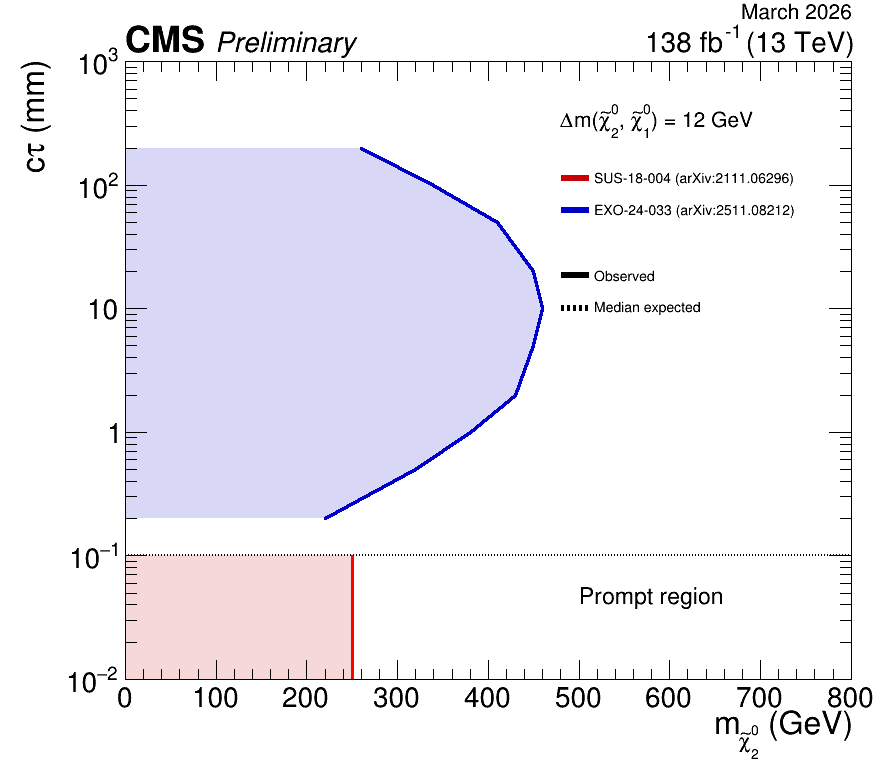

In [23]:
ROOT.gROOT.SetBatch(True)

# --- global style tweaks (CMS-like) ---
ROOT.gStyle.SetOptStat(0)
ROOT.gStyle.SetPadTickX(1)
ROOT.gStyle.SetPadTickY(1)

def make_graph(x, y, sort=2):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    m = np.isfinite(x) & np.isfinite(y)
    x = x[m]
    y = y[m]

    if sort == 2:
        order = np.argsort(y)
    elif sort == 1:
        order = np.argsort(x)
    else:
        order = np.arange(len(x))

    x = x[order]
    y = y[order]

    return ROOT.TGraph(len(x), array("d", x.tolist()), array("d", y.tolist()))

def make_left_exclusion(graph, xmin):
    """
    Create filled polygon for region LEFT of curve.
    Assumes graph is ordered in y.
    """
    n = graph.GetN()

    xs = [graph.GetPointX(i) for i in range(n)]
    ys = [graph.GetPointY(i) for i in range(n)]

    x0, y0 = xs[0], ys[0]
    x1, y1 = xs[-1], ys[-1]

    poly_x = [xmin, x0] + xs + [xmin, xmin]
    poly_y = [y0,   y0] + ys + [y1,   y0]

    return ROOT.TGraph(
        len(poly_x),
        array("d", poly_x),
        array("d", poly_y),
    )

# -----------------------------
# input columns
# -----------------------------
xcol = r'Observed $m$ excluded at 95%% CL [GeV]'
ycol = r'$c\tau$ [mm]'

# --- build observed graph ---
g_obs = make_graph(
    exo_24_033_12_obs[xcol],
    exo_24_033_12_obs[ycol],
    sort=2,
)

# --- style ---
g_obs.SetLineColor(ROOT.kBlue + 1)
g_obs.SetLineWidth(3)

# --- canvas ---
c = ROOT.TCanvas("c", "", 900, 800)
c.SetLogy()

c.SetLeftMargin(0.14)
c.SetRightMargin(0.05)
c.SetTopMargin(0.08)
c.SetBottomMargin(0.12)

xmin, xmax = 0, 800
ymin, ymax = 1e-2, 1e3

# --- frame ---
frame = ROOT.TH1F("frame", "", 100, xmin, xmax)
frame.SetMinimum(ymin)
frame.SetMaximum(ymax)

frame.GetXaxis().SetTitle("m_{#tilde{#chi}^{0}_{2}} (GeV)")
frame.GetYaxis().SetTitle("c#tau (mm)")

frame.GetXaxis().SetTitleSize(0.045)
frame.GetYaxis().SetTitleSize(0.045)
frame.GetXaxis().SetLabelSize(0.04)
frame.GetYaxis().SetLabelSize(0.04)
frame.GetYaxis().SetTitleOffset(1.4)

frame.Draw()

# --- shaded exclusion region ---
h_obs = make_left_exclusion(g_obs, xmin)
h_obs.SetFillColorAlpha(ROOT.kBlue + 1, 0.15)
h_obs.SetLineWidth(0)
h_obs.Draw("F SAME")

# --- observed curve ---
g_obs.Draw("L SAME")

# --- shaded prompt region to the left of the vertical line ---
prompt_box = ROOT.TBox(xmin, ymin, 250, 0.1)
prompt_box.SetFillColorAlpha(ROOT.kRed + 1, 0.15)
prompt_box.SetLineWidth(0)
prompt_box.Draw("SAME")

# --- prompt diagonal line: plt.plot([0, 250], [0, 0.1], 'r-')
ymin = frame.GetMinimum()
ymax = frame.GetMaximum()

line = ROOT.TLine(250, ymin, 250, 0.1)
line.SetLineStyle(1)
line.SetLineColor(ROOT.kRed)
line.SetLineWidth(3)
line.Draw()

# --- horizontal dashed line: plt.hlines(0.1, 0, 1e8, ...)
line_ctau = ROOT.TLine(xmin, 0.1, xmax, 0.1)
line_ctau.SetLineColor(ROOT.kBlack)
line_ctau.SetLineStyle(3)
line_ctau.SetLineWidth(2)
line_ctau.Draw("SAME")

# --- text ---
latex = ROOT.TLatex()
latex.SetNDC(False)
latex.SetTextFont(42)
latex.SetTextSize(0.032)
latex.DrawLatex(500, 0.04, "Prompt region")



# --- legend ---
leg_obs = ROOT.TLine()
leg_obs.SetLineColor(ROOT.kBlack)
leg_obs.SetLineWidth(6)
leg_obs.SetLineStyle(1)

leg_exp = ROOT.TLine()
leg_exp.SetLineColor(ROOT.kBlack)
leg_exp.SetLineWidth(6)
leg_exp.SetLineStyle(2)

# dummy objects for legend
leg_sus_18_004 = ROOT.TLine()
leg_sus_18_004.SetLineColor(ROOT.kRed+1)
leg_sus_18_004.SetLineWidth(6)

leg_exo_24_033 = ROOT.TLine()
leg_exo_24_033.SetLineColor(ROOT.kBlue+1)
leg_exo_24_033.SetLineWidth(6)



leg = ROOT.TLegend(0.62,0.58,0.91,0.79)
leg.SetBorderSize(0)
leg.SetFillColor(ROOT.kWhite)


leg.AddEntry(leg_sus_18_004, "SUS-18-004 (arXiv:2111.06296)", "l")
leg.AddEntry(leg_exo_24_033, "EXO-24-033 (arXiv:2511.08212)", "l")

# spacer
leg.AddEntry(0, "", "")

# line-style explanation
leg.AddEntry(leg_obs, "Observed", "l")
leg.AddEntry(leg_exp, "Median expected", "l")

leg.SetMargin(0.15)
leg.Draw()

# --- CMS labels ---
latex_ndc = ROOT.TLatex()
latex_ndc.SetNDC()

latex_ndc.SetTextFont(62)
latex_ndc.SetTextSize(0.05)
latex_ndc.DrawLatex(0.14, 0.932, "CMS")

latex_ndc.SetTextFont(52)
latex_ndc.SetTextSize(0.04)
latex_ndc.DrawLatex(0.24, 0.932, "Preliminary")

latex_ndc.SetTextFont(42)
latex_ndc.SetTextSize(0.04)
latex_ndc.DrawLatex(0.72, 0.932, "138 fb^{-1} (13 TeV)")

latex_ndc.SetTextFont(42)
latex_ndc.SetTextSize(0.03)
latex_ndc.DrawLatex(0.828,0.975,"March 2026")

latex_ndc.SetTextFont(42)
latex_ndc.SetTextSize(0.03)
latex_ndc.DrawLatex(0.625,0.835,"#Deltam(#tilde{#chi}^{0}_{2}, #tilde{#chi}^{0}_{1}) = 12 GeV")

c.RedrawAxis()
c.Update()
c.Draw()

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Warning in <TROOT::Append>: Replacing existing TH1: frame (Potential memory leak).


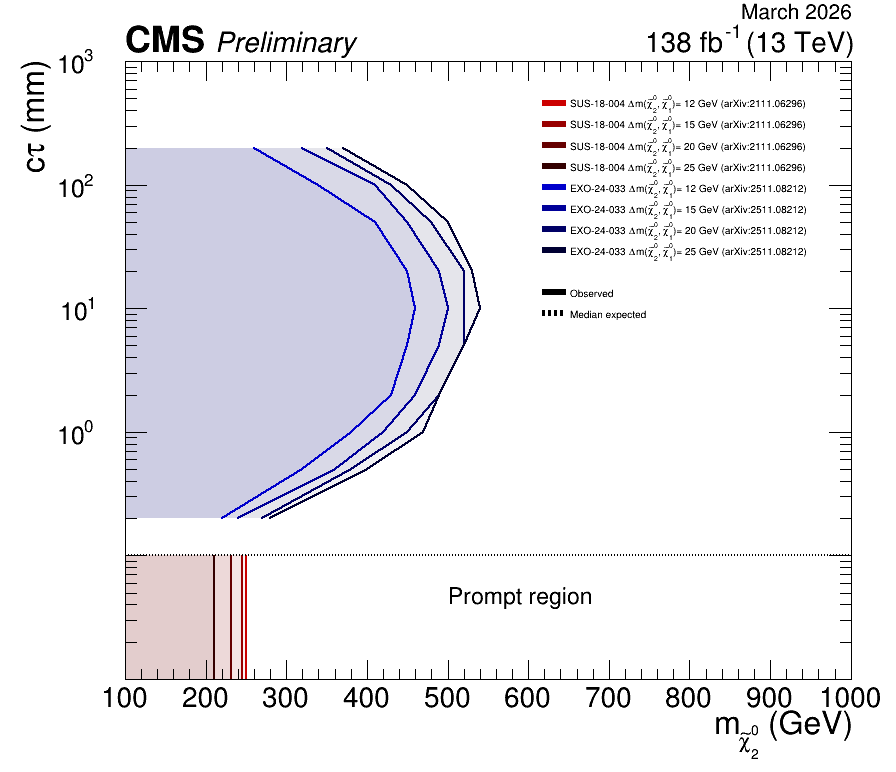

In [24]:
ROOT.gROOT.SetBatch(True)

# --- global style tweaks (CMS-like) ---
ROOT.gStyle.SetOptStat(0)
ROOT.gStyle.SetPadTickX(1)
ROOT.gStyle.SetPadTickY(1)

def make_graph(x, y, sort=2):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    m = np.isfinite(x) & np.isfinite(y)
    x = x[m]
    y = y[m]

    if sort == 2:
        order = np.argsort(y)
    elif sort == 1:
        order = np.argsort(x)
    else:
        order = np.arange(len(x))

    x = x[order]
    y = y[order]

    return ROOT.TGraph(len(x), array("d", x.tolist()), array("d", y.tolist()))

def make_left_exclusion(graph, xmin):
    """
    Create filled polygon for region LEFT of curve.
    Assumes graph is ordered in y.
    """
    n = graph.GetN()

    xs = [graph.GetPointX(i) for i in range(n)]
    ys = [graph.GetPointY(i) for i in range(n)]

    x0, y0 = xs[0], ys[0]
    x1, y1 = xs[-1], ys[-1]

    poly_x = [xmin, x0] + xs + [xmin, xmin]
    poly_y = [y0,   y0] + ys + [y1,   y0]

    return ROOT.TGraph(
        len(poly_x),
        array("d", poly_x),
        array("d", poly_y),
    )

# -----------------------------
# input columns
# -----------------------------
xcol = r'Observed $m$ excluded at 95%% CL [GeV]'
ycol = r'$c\tau$ [mm]'

# --- build observed graph ---
g_exo_24_033_12 = make_graph(exo_24_033_12_obs[xcol], exo_24_033_12_obs[ycol], sort=2)
g_exo_24_033_15 = make_graph(exo_24_033_15_obs[xcol], exo_24_033_15_obs[ycol], sort=2)
g_exo_24_033_20 = make_graph(exo_24_033_20_obs[xcol], exo_24_033_20_obs[ycol], sort=2)
g_exo_24_033_25 = make_graph(exo_24_033_25_obs[xcol], exo_24_033_25_obs[ycol], sort=2)

# --- style ---
g_exo_24_033_12.SetLineColor(ROOT.kBlue + 1)
g_exo_24_033_12.SetLineWidth(2)
g_exo_24_033_15.SetLineColor(ROOT.kBlue + 2)
g_exo_24_033_15.SetLineWidth(2)
g_exo_24_033_20.SetLineColor(ROOT.kBlue + 3)
g_exo_24_033_20.SetLineWidth(2)
g_exo_24_033_25.SetLineColor(ROOT.kBlue + 4)
g_exo_24_033_25.SetLineWidth(2)

# --- canvas ---
c = ROOT.TCanvas("c", "", 900, 800)
c.SetLogy()

c.SetLeftMargin(0.14)
c.SetRightMargin(0.05)
c.SetTopMargin(0.08)
c.SetBottomMargin(0.12)

xmin, xmax = 100, 1000
ymin, ymax = 1e-2, 1e3

# --- frame ---
frame = ROOT.TH1F("frame", "", 100, xmin, xmax)
frame.SetMinimum(ymin)
frame.SetMaximum(ymax)

frame.GetXaxis().SetTitle("m_{#tilde{#chi}^{0}_{2}} (GeV)")
frame.GetYaxis().SetTitle("c#tau (mm)")

frame.GetXaxis().SetTitleSize(0.045)
frame.GetYaxis().SetTitleSize(0.045)
frame.GetXaxis().SetLabelSize(0.04)
frame.GetYaxis().SetLabelSize(0.04)
frame.GetYaxis().SetTitleOffset(1.4)

frame.Draw()
frame.GetYaxis().SetMoreLogLabels(False)
frame.GetYaxis().SetNoExponent(True)
frame.GetYaxis().SetLabelOffset(999)  # hide labels

latex_axis = ROOT.TLatex()
latex_axis.SetTextFont(42)
latex_axis.SetTextSize(0.035)
latex_axis.SetTextAlign(32)

labels = [
    (1, "10^{0}"),
    (10, "10^{1}"),
    (100, "10^{2}"),
    (1000, "10^{3}")
]

for y, label in labels:
    latex_axis.DrawLatex(xmin - 40, y, label)

# --- shaded exclusion region ---
h_exo_24_033_12 = make_left_exclusion(g_exo_24_033_12, xmin)
h_exo_24_033_12.SetFillColorAlpha(ROOT.kBlue + 1, 0.05)
h_exo_24_033_12.SetLineWidth(0)
h_exo_24_033_12.Draw("F SAME")

h_exo_24_033_15 = make_left_exclusion(g_exo_24_033_15, xmin)
h_exo_24_033_15.SetFillColorAlpha(ROOT.kBlue + 2, 0.05)
h_exo_24_033_15.SetLineWidth(0)
h_exo_24_033_15.Draw("F SAME")

h_exo_24_033_20 = make_left_exclusion(g_exo_24_033_20, xmin)
h_exo_24_033_20.SetFillColorAlpha(ROOT.kBlue + 3, 0.05)
h_exo_24_033_20.SetLineWidth(0)
h_exo_24_033_20.Draw("F SAME")

h_exo_24_033_25 = make_left_exclusion(g_exo_24_033_25, xmin)
h_exo_24_033_25.SetFillColorAlpha(ROOT.kBlue + 4, 0.05)
h_exo_24_033_25.SetLineWidth(0)
h_exo_24_033_25.Draw("F SAME")

# --- observed curve ---
g_exo_24_033_12.Draw("L SAME")
g_exo_24_033_15.Draw("L SAME")
g_exo_24_033_20.Draw("L SAME")
g_exo_24_033_25.Draw("L SAME")

# --- shaded prompt region to the left of the vertical line ---
ymin = frame.GetMinimum()

h_sus_18_004_12 = ROOT.TBox(xmin, ymin, 250, 0.1)
h_sus_18_004_12.SetFillColorAlpha(ROOT.kRed + 1, 0.05)
h_sus_18_004_12.SetLineWidth(0)
h_sus_18_004_12.Draw("SAME")

g_sus_18_004_12 = ROOT.TLine(250, ymin, 250, 0.1)
g_sus_18_004_12.SetLineStyle(1)
g_sus_18_004_12.SetLineColor(ROOT.kRed + 1)
g_sus_18_004_12.SetLineWidth(2)
g_sus_18_004_12.Draw()

h_sus_18_004_15 = ROOT.TBox(xmin, ymin, 245, 0.1)
h_sus_18_004_15.SetFillColorAlpha(ROOT.kRed + 2, 0.05)
h_sus_18_004_15.SetLineWidth(0)
h_sus_18_004_15.Draw("SAME")

g_sus_18_004_15 = ROOT.TLine(245, ymin, 245, 0.1)
g_sus_18_004_15.SetLineStyle(1)
g_sus_18_004_15.SetLineColor(ROOT.kRed + 2)
g_sus_18_004_15.SetLineWidth(2)
g_sus_18_004_15.Draw()

h_sus_18_004_20 = ROOT.TBox(xmin, ymin, 231, 0.1)
h_sus_18_004_20.SetFillColorAlpha(ROOT.kRed + 3, 0.05)
h_sus_18_004_20.SetLineWidth(0)
h_sus_18_004_20.Draw("SAME")

g_sus_18_004_20 = ROOT.TLine(231, ymin, 231, 0.1)
g_sus_18_004_20.SetLineStyle(1)
g_sus_18_004_20.SetLineColor(ROOT.kRed + 3)
g_sus_18_004_20.SetLineWidth(2)
g_sus_18_004_20.Draw()

h_sus_18_004_25 = ROOT.TBox(xmin, ymin, 210, 0.1)
h_sus_18_004_25.SetFillColorAlpha(ROOT.kRed + 4, 0.05)
h_sus_18_004_25.SetLineWidth(0)
h_sus_18_004_25.Draw("SAME")

g_sus_18_004_25 = ROOT.TLine(210, ymin, 210, 0.1)
g_sus_18_004_25.SetLineStyle(1)
g_sus_18_004_25.SetLineColor(ROOT.kRed + 4)
g_sus_18_004_25.SetLineWidth(2)
g_sus_18_004_25.Draw()

# --- horizontal dashed line: plt.hlines(0.1, 0, 1e8, ...)
line_ctau = ROOT.TLine(xmin, 0.1, xmax, 0.1)
line_ctau.SetLineColor(ROOT.kBlack)
line_ctau.SetLineStyle(3)
line_ctau.SetLineWidth(2)
line_ctau.Draw("SAME")

# --- text ---
latex = ROOT.TLatex()
latex.SetNDC(False)
latex.SetTextFont(42)
latex.SetTextSize(0.032)
latex.DrawLatex(500, 0.04, "Prompt region")

# --- legend ---
leg_obs = ROOT.TLine()
leg_obs.SetLineColor(ROOT.kBlack)
leg_obs.SetLineWidth(6)
leg_obs.SetLineStyle(1)

leg_exp = ROOT.TLine()
leg_exp.SetLineColor(ROOT.kBlack)
leg_exp.SetLineWidth(6)
leg_exp.SetLineStyle(2)

# dummy objects for legend
leg_sus_18_004_12 = ROOT.TLine()
leg_sus_18_004_12.SetLineColor(ROOT.kRed+1)
leg_sus_18_004_12.SetLineWidth(6)

leg_sus_18_004_15 = ROOT.TLine()
leg_sus_18_004_15.SetLineColor(ROOT.kRed+2)
leg_sus_18_004_15.SetLineWidth(6)

leg_sus_18_004_20 = ROOT.TLine()
leg_sus_18_004_20.SetLineColor(ROOT.kRed+3)
leg_sus_18_004_20.SetLineWidth(6)

leg_sus_18_004_25 = ROOT.TLine()
leg_sus_18_004_25.SetLineColor(ROOT.kRed+4)
leg_sus_18_004_25.SetLineWidth(6)

leg_exo_24_033_12 = ROOT.TLine()
leg_exo_24_033_12.SetLineColor(ROOT.kBlue+1)
leg_exo_24_033_12.SetLineWidth(6)

leg_exo_24_033_15 = ROOT.TLine()
leg_exo_24_033_15.SetLineColor(ROOT.kBlue+2)
leg_exo_24_033_15.SetLineWidth(6)

leg_exo_24_033_20 = ROOT.TLine()
leg_exo_24_033_20.SetLineColor(ROOT.kBlue+3)
leg_exo_24_033_20.SetLineWidth(6)

leg_exo_24_033_25 = ROOT.TLine()
leg_exo_24_033_25.SetLineColor(ROOT.kBlue+4)
leg_exo_24_033_25.SetLineWidth(6)



leg = ROOT.TLegend(0.60,0.58,0.91,0.88)
leg.SetBorderSize(0)
leg.SetFillColor(ROOT.kWhite)


leg.AddEntry(leg_sus_18_004_12, "SUS-18-004 #Deltam(#tilde{#chi}^{0}_{2}, #tilde{#chi}^{0}_{1})= 12 GeV (arXiv:2111.06296)", "l")
leg.AddEntry(leg_sus_18_004_15, "SUS-18-004 #Deltam(#tilde{#chi}^{0}_{2}, #tilde{#chi}^{0}_{1})= 15 GeV (arXiv:2111.06296)", "l")
leg.AddEntry(leg_sus_18_004_20, "SUS-18-004 #Deltam(#tilde{#chi}^{0}_{2}, #tilde{#chi}^{0}_{1})= 20 GeV (arXiv:2111.06296)", "l")
leg.AddEntry(leg_sus_18_004_25, "SUS-18-004 #Deltam(#tilde{#chi}^{0}_{2}, #tilde{#chi}^{0}_{1})= 25 GeV (arXiv:2111.06296)", "l")

leg.AddEntry(leg_exo_24_033_12, "EXO-24-033 #Deltam(#tilde{#chi}^{0}_{2}, #tilde{#chi}^{0}_{1})= 12 GeV (arXiv:2511.08212)", "l")
leg.AddEntry(leg_exo_24_033_15, "EXO-24-033 #Deltam(#tilde{#chi}^{0}_{2}, #tilde{#chi}^{0}_{1})= 15 GeV (arXiv:2511.08212)", "l")
leg.AddEntry(leg_exo_24_033_20, "EXO-24-033 #Deltam(#tilde{#chi}^{0}_{2}, #tilde{#chi}^{0}_{1})= 20 GeV (arXiv:2511.08212)", "l")
leg.AddEntry(leg_exo_24_033_25, "EXO-24-033 #Deltam(#tilde{#chi}^{0}_{2}, #tilde{#chi}^{0}_{1})= 25 GeV (arXiv:2511.08212)", "l")

# spacer
leg.AddEntry(0, "", "")

# line-style explanation
leg.AddEntry(leg_obs, "Observed", "l")
leg.AddEntry(leg_exp, "Median expected", "l")

leg.SetMargin(0.12)
leg.Draw()

# --- CMS labels ---
latex_ndc = ROOT.TLatex()
latex_ndc.SetNDC()

latex_ndc.SetTextFont(62)
latex_ndc.SetTextSize(0.05)
latex_ndc.DrawLatex(0.14, 0.932, "CMS")

latex_ndc.SetTextFont(52)
latex_ndc.SetTextSize(0.04)
latex_ndc.DrawLatex(0.24, 0.932, "Preliminary")

latex_ndc.SetTextFont(42)
latex_ndc.SetTextSize(0.04)
latex_ndc.DrawLatex(0.72, 0.932, "138 fb^{-1} (13 TeV)")

latex_ndc.SetTextFont(42)
latex_ndc.SetTextSize(0.03)
latex_ndc.DrawLatex(0.828,0.975,"March 2026")

# latex_ndc.SetTextFont(42)
# latex_ndc.SetTextSize(0.03)
# latex_ndc.DrawLatex(0.625,0.835,"#Deltam(#tilde{#chi}^{0}_{2}, #tilde{#chi}^{0}_{1}) = 12 GeV")

c.RedrawAxis()
c.Update()
c.Draw()

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Warning in <TROOT::Append>: Replacing existing TH1: frame (Potential memory leak).


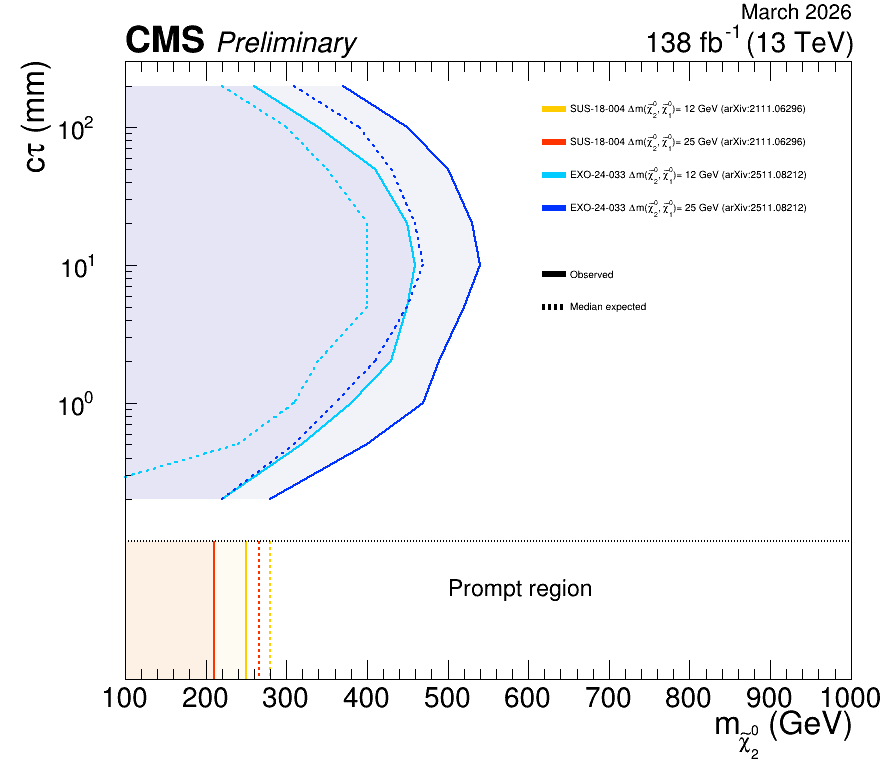

In [13]:
import ROOT
import numpy as np
from array import array

ROOT.gROOT.SetBatch(True)

# --- global style tweaks (CMS-like) ---
ROOT.gStyle.SetOptStat(0)
ROOT.gStyle.SetPadTickX(1)
ROOT.gStyle.SetPadTickY(1)

def make_graph(x, y, sort=2):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    m = np.isfinite(x) & np.isfinite(y)
    x = x[m]
    y = y[m]

    if sort == 2:
        order = np.argsort(y)
    elif sort == 1:
        order = np.argsort(x)
    else:
        order = np.arange(len(x))

    x = x[order]
    y = y[order]

    return ROOT.TGraph(len(x), array("d", x.tolist()), array("d", y.tolist()))

def make_left_exclusion(graph, xmin):
    """
    Create filled polygon for region LEFT of curve.
    Assumes graph is ordered in y.
    """
    n = graph.GetN()

    xs = [graph.GetPointX(i) for i in range(n)]
    ys = [graph.GetPointY(i) for i in range(n)]

    x0, y0 = xs[0], ys[0]
    x1, y1 = xs[-1], ys[-1]

    poly_x = [xmin, x0] + xs + [xmin, xmin]
    poly_y = [y0,   y0] + ys + [y1,   y0]

    return ROOT.TGraph(
        len(poly_x),
        array("d", poly_x),
        array("d", poly_y),
    )

# -----------------------------
# input columns
# -----------------------------
xcol = r'Observed $m$ excluded at 95%% CL [GeV]'
xcol_exp = r'Median expected $m$ excluded at 95%% CL [GeV]'
ycol = r'$c\tau$ [mm]'

# --- build observed graph ---
g_exo_24_033_12 = make_graph(exo_24_033_12_obs[xcol], exo_24_033_12_obs[ycol], sort=2)
g_exo_24_033_25 = make_graph(exo_24_033_25_obs[xcol], exo_24_033_25_obs[ycol], sort=2)

g_exo_24_033_12_exp = make_graph(exo_24_033_12_exp[xcol_exp], exo_24_033_12_exp[ycol], sort=2)
g_exo_24_033_25_exp = make_graph(exo_24_033_25_exp[xcol_exp], exo_24_033_25_exp[ycol], sort=2)

# --- style ---
g_exo_24_033_12.SetLineColor(ROOT.kAzure + 10)
g_exo_24_033_12.SetLineWidth(2)
g_exo_24_033_25.SetLineColor(ROOT.kAzure)
g_exo_24_033_25.SetLineWidth(2)

g_exo_24_033_12_exp.SetLineColor(ROOT.kAzure + 10)
g_exo_24_033_12_exp.SetLineWidth(2)
g_exo_24_033_12_exp.SetLineStyle(2)
g_exo_24_033_25_exp.SetLineColor(ROOT.kAzure)
g_exo_24_033_25_exp.SetLineWidth(2)
g_exo_24_033_25_exp.SetLineStyle(2)

# --- canvas ---
c = ROOT.TCanvas("c", "", 900, 800)
c.SetLogy()

c.SetLeftMargin(0.14)
c.SetRightMargin(0.05)
c.SetTopMargin(0.08)
c.SetBottomMargin(0.12)

xmin, xmax = 100, 1000
ymin, ymax = 1e-2, 3e2

# --- frame ---
frame = ROOT.TH1F("frame", "", 100, xmin, xmax)
frame.SetMinimum(ymin)
frame.SetMaximum(ymax)

frame.GetXaxis().SetTitle("m_{#tilde{#chi}^{0}_{2}} (GeV)")
frame.GetYaxis().SetTitle("c#tau (mm)")

frame.GetXaxis().SetTitleSize(0.045)
frame.GetYaxis().SetTitleSize(0.045)
frame.GetXaxis().SetLabelSize(0.04)
frame.GetYaxis().SetLabelSize(0.04)
frame.GetYaxis().SetTitleOffset(1.4)

frame.Draw()

# -------------------------------------------------
# Hide ROOT y-axis ticks and labels
# -------------------------------------------------
frame.GetYaxis().SetTickLength(0)
frame.GetYaxis().SetMoreLogLabels(False)
frame.GetYaxis().SetNoExponent(True)
frame.GetYaxis().SetLabelOffset(999)

# -------------------------------------------------
# Draw custom major + minor ticks only for y >= 1e-1
# -------------------------------------------------
major_tick = ROOT.TLine()
major_tick.SetLineWidth(1)

minor_tick = ROOT.TLine()
minor_tick.SetLineWidth(1)

major_len = (xmax - xmin) * 0.015
minor_len = (xmax - xmin) * 0.008

# major decades to keep
major_ticks = [1, 10, 100]

for y in major_ticks:
    if ymin <= y <= ymax:
        major_tick.DrawLine(xmin, y, xmin + major_len, y)

# minor ticks between decades:
# 2..9 * 10^n, but only above 1e-1
for decade in [-1, 0, 1, 2]:
    base = 10 ** decade
    for m in range(2, 10):
        y = m * base
        if y < 1e-1:
            continue
        if ymin <= y <= ymax:
            minor_tick.DrawLine(xmin, y, xmin + minor_len, y)

# -------------------------------------------------
# Draw custom y-axis labels
# -------------------------------------------------
latex_axis = ROOT.TLatex()
latex_axis.SetTextFont(42)
latex_axis.SetTextSize(0.035)
latex_axis.SetTextAlign(32)

labels = [
    (1, "10^{0}"),
    (10, "10^{1}"),
    (100, "10^{2}"),
]

for y, label in labels:
    latex_axis.DrawLatex(xmin - 40, y, label)

# --- shaded exclusion region ---
h_exo_24_033_12 = make_left_exclusion(g_exo_24_033_12, xmin)
h_exo_24_033_12.SetFillColorAlpha(ROOT.kBlue + 1, 0.05)
h_exo_24_033_12.SetLineWidth(0)
h_exo_24_033_12.Draw("F SAME")

h_exo_24_033_25 = make_left_exclusion(g_exo_24_033_25, xmin)
h_exo_24_033_25.SetFillColorAlpha(ROOT.kBlue + 2, 0.05)
h_exo_24_033_25.SetLineWidth(0)
h_exo_24_033_25.Draw("F SAME")

# --- observed curve ---
g_exo_24_033_12.Draw("L SAME")
g_exo_24_033_25.Draw("L SAME")
g_exo_24_033_12_exp.Draw("L SAME")
g_exo_24_033_25_exp.Draw("L SAME")

# --- shaded prompt region to the left of the vertical line ---
ymin_frame = frame.GetMinimum()

h_sus_18_004_12 = ROOT.TBox(xmin, ymin_frame, 250, 0.1)
h_sus_18_004_12.SetFillColorAlpha(ROOT.kOrange, 0.05)
h_sus_18_004_12.SetLineWidth(0)
h_sus_18_004_12.Draw("SAME")

g_sus_18_004_12 = ROOT.TLine(250, ymin_frame, 250, 0.1)
g_sus_18_004_12.SetLineStyle(1)
g_sus_18_004_12.SetLineColor(ROOT.kOrange)
g_sus_18_004_12.SetLineWidth(2)
g_sus_18_004_12.Draw()

g_sus_18_004_12_exp = ROOT.TLine(280, ymin_frame, 280, 0.1)
g_sus_18_004_12_exp.SetLineStyle(2)
g_sus_18_004_12_exp.SetLineColor(ROOT.kOrange)
g_sus_18_004_12_exp.SetLineWidth(2)
g_sus_18_004_12_exp.Draw()

h_sus_18_004_25 = ROOT.TBox(xmin, ymin_frame, 210, 0.1)
h_sus_18_004_25.SetFillColorAlpha(ROOT.kOrange+10, 0.05)
h_sus_18_004_25.SetLineWidth(0)
h_sus_18_004_25.Draw("SAME")

g_sus_18_004_25 = ROOT.TLine(210, ymin_frame, 210, 0.1)
g_sus_18_004_25.SetLineStyle(1)
g_sus_18_004_25.SetLineColor(ROOT.kOrange+10)
g_sus_18_004_25.SetLineWidth(2)
g_sus_18_004_25.Draw()

g_sus_18_004_25_exp = ROOT.TLine(266, ymin_frame, 266, 0.1)
g_sus_18_004_25_exp.SetLineStyle(2)
g_sus_18_004_25_exp.SetLineColor(ROOT.kOrange+10)
g_sus_18_004_25_exp.SetLineWidth(2)
g_sus_18_004_25_exp.Draw()

# --- horizontal dashed line ---
line_ctau = ROOT.TLine(xmin, 0.1, xmax, 0.1)
line_ctau.SetLineColor(ROOT.kBlack)
line_ctau.SetLineStyle(3)
line_ctau.SetLineWidth(2)
line_ctau.Draw("SAME")

# --- text ---
latex = ROOT.TLatex()
latex.SetNDC(False)
latex.SetTextFont(42)
latex.SetTextSize(0.032)
latex.DrawLatex(500, 0.04, "Prompt region")

# --- legend ---
leg_obs = ROOT.TLine()
leg_obs.SetLineColor(ROOT.kBlack)
leg_obs.SetLineWidth(6)
leg_obs.SetLineStyle(1)

leg_exp = ROOT.TLine()
leg_exp.SetLineColor(ROOT.kBlack)
leg_exp.SetLineWidth(6)
leg_exp.SetLineStyle(2)

leg_sus_18_004_12 = ROOT.TLine()
leg_sus_18_004_12.SetLineColor(ROOT.kOrange)
leg_sus_18_004_12.SetLineWidth(6)

leg_sus_18_004_25 = ROOT.TLine()
leg_sus_18_004_25.SetLineColor(ROOT.kOrange+10)
leg_sus_18_004_25.SetLineWidth(6)

leg_exo_24_033_12 = ROOT.TLine()
leg_exo_24_033_12.SetLineColor(ROOT.kAzure+10)
leg_exo_24_033_12.SetLineWidth(6)

leg_exo_24_033_25 = ROOT.TLine()
leg_exo_24_033_25.SetLineColor(ROOT.kAzure)
leg_exo_24_033_25.SetLineWidth(6)

leg = ROOT.TLegend(0.60,0.58,0.91,0.88)
leg.SetBorderSize(0)
leg.SetFillColor(ROOT.kWhite)

leg.AddEntry(leg_sus_18_004_12, "SUS-18-004 #Deltam(#tilde{#chi}^{0}_{2}, #tilde{#chi}^{0}_{1})= 12 GeV (arXiv:2111.06296)", "l")
leg.AddEntry(leg_sus_18_004_25, "SUS-18-004 #Deltam(#tilde{#chi}^{0}_{2}, #tilde{#chi}^{0}_{1})= 25 GeV (arXiv:2111.06296)", "l")
leg.AddEntry(leg_exo_24_033_12, "EXO-24-033 #Deltam(#tilde{#chi}^{0}_{2}, #tilde{#chi}^{0}_{1})= 12 GeV (arXiv:2511.08212)", "l")
leg.AddEntry(leg_exo_24_033_25, "EXO-24-033 #Deltam(#tilde{#chi}^{0}_{2}, #tilde{#chi}^{0}_{1})= 25 GeV (arXiv:2511.08212)", "l")

leg.AddEntry(0, "", "")
leg.AddEntry(leg_obs, "Observed", "l")
leg.AddEntry(leg_exp, "Median expected", "l")

leg.SetMargin(0.12)
leg.Draw()

# --- CMS labels ---
latex_ndc = ROOT.TLatex()
latex_ndc.SetNDC()

latex_ndc.SetTextFont(62)
latex_ndc.SetTextSize(0.05)
latex_ndc.DrawLatex(0.14, 0.932, "CMS")

latex_ndc.SetTextFont(52)
latex_ndc.SetTextSize(0.04)
latex_ndc.DrawLatex(0.24, 0.932, "Preliminary")

latex_ndc.SetTextFont(42)
latex_ndc.SetTextSize(0.04)
latex_ndc.DrawLatex(0.72, 0.932, "138 fb^{-1} (13 TeV)")

latex_ndc.SetTextFont(42)
latex_ndc.SetTextSize(0.03)
latex_ndc.DrawLatex(0.828, 0.975, "March 2026")

c.RedrawAxis()
c.Update()
c.Draw()

In [143]:
import re
import requests
import pandas as pd
from io import StringIO

url = "https://twiki.cern.ch/twiki/bin/view/LHCPhysics/SUSYCrossSections13TeVn2x1wino?raw=on"
text = requests.get(url, timeout=30).text

lines = text.splitlines()

# collect the first table: first contiguous block of lines starting with "|"
table_lines = []
inside_table = False

for line in lines:
    if line.startswith("|"):
        table_lines.append(line)
        inside_table = True
    elif inside_table:
        break

# convert TWiki rows like:
# | *Mass (GeV)* | *Cross section (pb)* | ...
# into CSV-ish rows
clean_rows = []
for line in table_lines:
    row = line.strip().strip("|")
    cells = [c.strip() for c in row.split("|")]

    # remove TWiki bold markers *...*
    cells = [re.sub(r"^\*(.*?)\*$", r"\1", c) for c in cells]

    clean_rows.append(",".join(f'"{c}"' for c in cells))

csv_text = "\n".join(clean_rows)

df = pd.read_csv(StringIO(csv_text))
xs_df = df.rename(columns={'m&lt;sub&gt;&amp;#967;&amp;#771;&lt;/sub&gt; [GeV]': 'M [GeV]'})
xs_df

,M [GeV],xsec [fb],uncertainty [fb]
0,100,22670.100000,973.967000
1,125,10034.800000,457.604000
2,150,5180.860000,253.223000
3,175,2953.280000,154.386000
4,200,1807.390000,101.316000
...,...,...,...
72,1900,0.009373,0.002986
73,1925,0.008148,0.002712
74,1950,0.007137,0.002444
75,1975,0.006220,0.002236


In [155]:
sus_18_004_mins_obs_merged = pd.merge(left=sus_18_004_mins_obs, right=xs_df, left_on=r'$m_{\tilde{\chi}^\pm_1} = m_{\tilde{\chi}^0_2}$ [GeV]', right_on='M [GeV]')
sus_18_004_mins_obs_merged['xsec [pb]'] = sus_18_004_mins_obs_merged['xsec [fb]'] / 1e3
exclude_mask = sus_18_004_mins_obs_merged['95% CL upper limit on the cross section [pb]'] < sus_18_004_mins_obs_merged['xsec [pb]']
sus_18_004_mins_obs_merged['exclude'] = exclude_mask
sus_18_004_mins_obs_merged_tmp = sus_18_004_mins_obs_merged
sus_18_004_mins_obs_merged = sus_18_004_mins_obs_merged[exclude_mask]



# ------------------------------------------------------------------------
# remove spurious exclusion to match the paper

mask = (
    (sus_18_004_mins_obs_merged[r'$m_{\tilde{\chi}^\pm_1} = m_{\tilde{\chi}^0_2}$ [GeV]'] == 175) &
    (sus_18_004_mins_obs_merged[r'$\Delta m (\tilde{\chi}^0_2, \tilde{\chi}^0_1)$ [GeV]'] == 40)
)

sus_18_004_mins_obs_merged_tmp = sus_18_004_mins_obs_merged
sus_18_004_mins_obs_merged = sus_18_004_mins_obs_merged[~mask]


# ------------------------------------------------------------------------

sus_18_004_mins_obs_merged = sus_18_004_mins_obs_merged.sort_values([
    r'$m_{\tilde{\chi}^\pm_1} = m_{\tilde{\chi}^0_2}$ [GeV]',
    r'$\Delta m (\tilde{\chi}^0_2, \tilde{\chi}^0_1)$ [GeV]'
])


sus_18_004_mins_obs_max = (
    sus_18_004_mins_obs_merged
    .sort_values(r'$m_{\tilde{\chi}^\pm_1} = m_{\tilde{\chi}^0_2}$ [GeV]')
    .groupby(r'$\Delta m (\tilde{\chi}^0_2, \tilde{\chi}^0_1)$ [GeV]', as_index=False)
    .last()
)

In [158]:
sus_18_004_mins_exp_merged = pd.merge(left=sus_18_004_mins_exp, right=xs_df, left_on=r'$m_{\tilde{\chi}^\pm_1} = m_{\tilde{\chi}^0_2}$ [GeV]', right_on='M [GeV]')
sus_18_004_mins_exp_merged['xsec [pb]'] = sus_18_004_mins_exp_merged['xsec [fb]'] / 1e3
exclude_mask = sus_18_004_mins_exp_merged['95% CL upper limit on the cross section [pb]'] < sus_18_004_mins_exp_merged['xsec [pb]']
sus_18_004_mins_exp_merged['exclude'] = exclude_mask
sus_18_004_mins_exp_merged_tmp = sus_18_004_mins_exp_merged
sus_18_004_mins_exp_merged = sus_18_004_mins_exp_merged[exclude_mask]



# ------------------------------------------------------------------------
# remove spurious exclusion to match the paper

mask = (
    (sus_18_004_mins_exp_merged[r'$m_{\tilde{\chi}^\pm_1} = m_{\tilde{\chi}^0_2}$ [GeV]'] == 175) &
    (sus_18_004_mins_exp_merged[r'$\Delta m (\tilde{\chi}^0_2, \tilde{\chi}^0_1)$ [GeV]'] == 40)
)

sus_18_004_mins_exp_merged_tmp = sus_18_004_mins_exp_merged
sus_18_004_mins_exp_merged = sus_18_004_mins_exp_merged[~mask]


# ------------------------------------------------------------------------

sus_18_004_mins_exp_merged = sus_18_004_mins_exp_merged.sort_values([
    r'$m_{\tilde{\chi}^\pm_1} = m_{\tilde{\chi}^0_2}$ [GeV]',
    r'$\Delta m (\tilde{\chi}^0_2, \tilde{\chi}^0_1)$ [GeV]'
])


sus_18_004_mins_exp_max = (
    sus_18_004_mins_exp_merged
    .sort_values(r'$m_{\tilde{\chi}^\pm_1} = m_{\tilde{\chi}^0_2}$ [GeV]')
    .groupby(r'$\Delta m (\tilde{\chi}^0_2, \tilde{\chi}^0_1)$ [GeV]', as_index=False)
    .last()
)

In [ ]:
sus_18_004_plus_obs_merged = pd.merge(left=sus_18_004_plus_obs, right=xs_df, left_on=r'$m_{\tilde{\chi}^\pm_1} = m_{\tilde{\chi}^0_2}$ [GeV]', right_on='M [GeV]')
sus_18_004_plus_obs_merged['xsec [pb]'] = sus_18_004_plus_obs_merged['xsec [fb]'] / 1e3
exclude_mask = sus_18_004_plus_obs_merged['95% CL upper limit on the cross section [pb]'] < sus_18_004_plus_obs_merged['xsec [pb]']
sus_18_004_plus_obs_merged['exclude'] = exclude_mask
sus_18_004_plus_obs_merged_tmp = sus_18_004_plus_obs_merged
sus_18_004_plus_obs_merged = sus_18_004_plus_obs_merged[exclude_mask]


sus_18_004_plus_obs_merged = sus_18_004_plus_obs_merged.sort_values([
    r'$m_{\tilde{\chi}^\pm_1} = m_{\tilde{\chi}^0_2}$ [GeV]',
    r'$\Delta m (\tilde{\chi}^0_2, \tilde{\chi}^0_1)$ [GeV]'
])


sus_18_004_plus_obs_max = (
    sus_18_004_plus_obs_merged
    .sort_values(r'$m_{\tilde{\chi}^\pm_1} = m_{\tilde{\chi}^0_2}$ [GeV]')
    .groupby(r'$\Delta m (\tilde{\chi}^0_2, \tilde{\chi}^0_1)$ [GeV]', as_index=False)
    .last()
)

In [167]:
sus_18_004_plus_exp_merged = pd.merge(left=sus_18_004_plus_exp, right=xs_df, left_on=r'$m_{\tilde{\chi}^\pm_1} = m_{\tilde{\chi}^0_2}$ [GeV]', right_on='M [GeV]')
sus_18_004_plus_exp_merged['xsec [pb]'] = sus_18_004_plus_exp_merged['xsec [fb]'] / 1e3
exclude_mask = sus_18_004_plus_exp_merged['95% CL upper limit on the cross section [pb]'] < sus_18_004_plus_exp_merged['xsec [pb]']
sus_18_004_plus_exp_merged['exclude'] = exclude_mask
sus_18_004_plus_exp_merged_tmp = sus_18_004_plus_exp_merged
sus_18_004_plus_exp_merged = sus_18_004_plus_exp_merged[exclude_mask]



# ------------------------------------------------------------------------
# remove spurious exclusion to match the paper

mask = (
    (sus_18_004_plus_exp_merged[r'$m_{\tilde{\chi}^\pm_1} = m_{\tilde{\chi}^0_2}$ [GeV]'] == 175) &
    (sus_18_004_plus_exp_merged[r'$\Delta m (\tilde{\chi}^0_2, \tilde{\chi}^0_1)$ [GeV]'] == 40)
)

sus_18_004_plus_exp_merged_tmp = sus_18_004_plus_exp_merged
sus_18_004_plus_exp_merged = sus_18_004_plus_exp_merged[~mask]


# ------------------------------------------------------------------------

sus_18_004_plus_exp_merged = sus_18_004_plus_exp_merged.sort_values([
    r'$m_{\tilde{\chi}^\pm_1} = m_{\tilde{\chi}^0_2}$ [GeV]',
    r'$\Delta m (\tilde{\chi}^0_2, \tilde{\chi}^0_1)$ [GeV]'
])


sus_18_004_plus_exp_max = (
    sus_18_004_plus_exp_merged
    .sort_values(r'$m_{\tilde{\chi}^\pm_1} = m_{\tilde{\chi}^0_2}$ [GeV]')
    .groupby(r'$\Delta m (\tilde{\chi}^0_2, \tilde{\chi}^0_1)$ [GeV]', as_index=False)
    .last()
)

# PLOT

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Warning in <TROOT::Append>: Replacing existing TH1: frame (Potential memory leak).


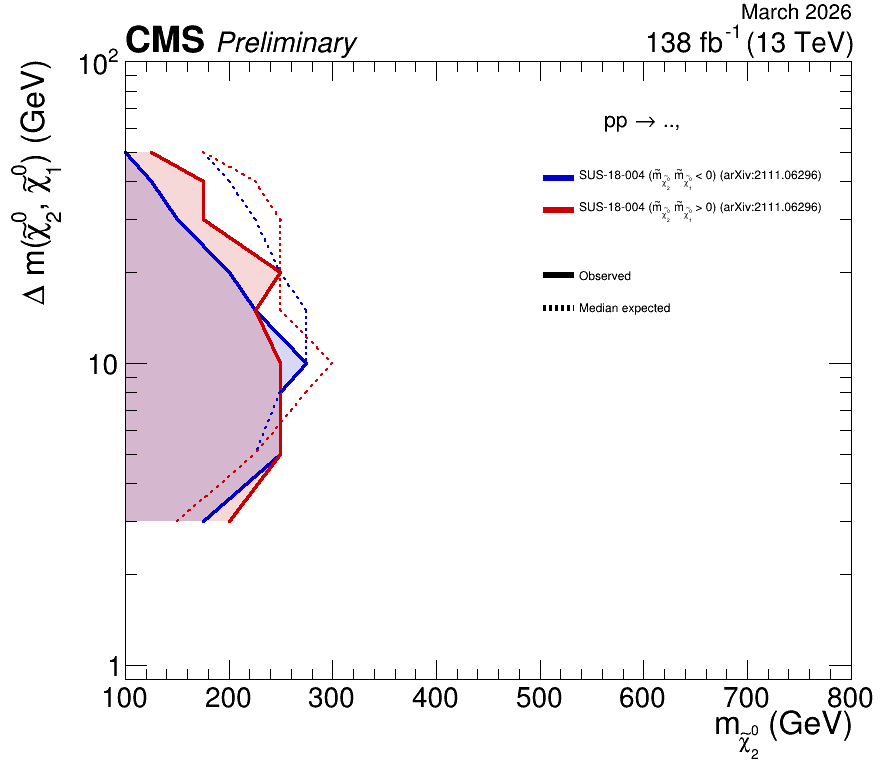

In [172]:
import ROOT
import numpy as np
from array import array

ROOT.gROOT.SetBatch(True)

# --- global style tweaks (CMS-like) ---
ROOT.gStyle.SetOptStat(0)
ROOT.gStyle.SetPadTickX(1)
ROOT.gStyle.SetPadTickY(1)

def make_graph(x, y, sort=2):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    m = np.isfinite(x) & np.isfinite(y)
    x = x[m]
    y = y[m]

    if sort == 2:
        order = np.argsort(y)  # important for proper polygon
    elif sort == 1:
        order = np.argsort(x)  # important for proper polygon

    x = x[order]
    y = y[order]

    return ROOT.TGraph(len(x), array("d", x.tolist()), array("d", y.tolist()))

def make_left_exclusion(graph, xmin):
    """
    Create filled polygon for region LEFT of curve.
    """
    n = graph.GetN()

    xs = [graph.GetPointX(i) for i in range(n)]
    ys = [graph.GetPointY(i) for i in range(n)]

    x0, y0 = xs[0], ys[0]
    x1, y1 = xs[-1], ys[-1]

    poly_x = [xmin, x0] + xs + [xmin, xmin]
    poly_y = [y0,   y0] + ys + [y1,   y0]

    return ROOT.TGraph(len(poly_x),
                       array("d", poly_x),
                       array("d", poly_y))


# --- build graphs ---
g_sus_18_004_mins_obs = make_graph(
    sus_18_004_mins_obs_max[r'$m_{\tilde{\chi}^\pm_1} = m_{\tilde{\chi}^0_2}$ [GeV]'],
    sus_18_004_mins_obs_max[r'$\Delta m (\tilde{\chi}^0_2, \tilde{\chi}^0_1)$ [GeV]'],
    sort=2
)
g_sus_18_004_plus_obs = make_graph(
    sus_18_004_plus_obs_max[r'$m_{\tilde{\chi}^\pm_1} = m_{\tilde{\chi}^0_2}$ [GeV]'],
    sus_18_004_plus_obs_max[r'$\Delta m (\tilde{\chi}^0_2, \tilde{\chi}^0_1)$ [GeV]'],
    sort=2
)
g_sus18004_mins_exp = make_graph(
    sus_18_004_mins_exp_max[r'$m_{\tilde{\chi}^\pm_1} = m_{\tilde{\chi}^0_2}$ [GeV]'],
    sus_18_004_mins_exp_max[r'$\Delta m (\tilde{\chi}^0_2, \tilde{\chi}^0_1)$ [GeV]'],
    sort=2
)
g_sus18004_plus_exp = make_graph(
    sus_18_004_plus_exp_max[r'$m_{\tilde{\chi}^\pm_1} = m_{\tilde{\chi}^0_2}$ [GeV]'],
    sus_18_004_plus_exp_max[r'$\Delta m (\tilde{\chi}^0_2, \tilde{\chi}^0_1)$ [GeV]'],
    sort=2
)



# --- style ---
g_sus_18_004_mins_obs.SetLineColor(ROOT.kBlue+1)
g_sus_18_004_mins_obs.SetLineWidth(3)

g_sus_18_004_plus_obs.SetLineColor(ROOT.kRed+1)
g_sus_18_004_plus_obs.SetLineWidth(3)

g_sus18004_mins_exp.SetLineColor(ROOT.kBlue+1)
g_sus18004_mins_exp.SetLineWidth(2)
g_sus18004_mins_exp.SetLineStyle(2)

g_sus18004_plus_exp.SetLineColor(ROOT.kRed+1)
g_sus18004_plus_exp.SetLineWidth(2)
g_sus18004_plus_exp.SetLineStyle(2)



# --- canvas ---
c = ROOT.TCanvas("c","",900,800)
c.SetLogy()

c.SetLeftMargin(0.14)
c.SetRightMargin(0.05)
c.SetTopMargin(0.08)
c.SetBottomMargin(0.12)

xmin, xmax = 100, 800
ymin, ymax = 0.9, 100

# --- frame ---
frame = ROOT.TH1F("frame","",100,xmin,xmax)
frame.SetMinimum(ymin)
frame.SetMaximum(ymax)

frame.GetXaxis().SetTitle("m_{#tilde{#chi}^{0}_{2}} (GeV)")
frame.GetYaxis().SetTitle("#Delta m(#tilde{#chi}^{0}_{2}, #tilde{#chi}^{0}_{1}) (GeV)")

frame.GetXaxis().SetTitleSize(0.045)
frame.GetYaxis().SetTitleSize(0.045)
frame.GetXaxis().SetLabelSize(0.04)
frame.GetYaxis().SetLabelSize(0.04)

frame.GetYaxis().SetTitleOffset(1.4)

frame.Draw()


# --- shaded exclusion regions ---
h_sus18004_mins = make_left_exclusion(g_sus_18_004_mins_obs, xmin)
h_sus18004_mins.SetFillColorAlpha(ROOT.kBlue+1,0.15)
h_sus18004_mins.SetLineWidth(0)
h_sus18004_mins.Draw("F SAME")

h_sus18004_plus = make_left_exclusion(g_sus_18_004_plus_obs, xmin)
h_sus18004_plus.SetFillColorAlpha(ROOT.kRed+1,0.15)
h_sus18004_plus.SetLineWidth(0)
h_sus18004_plus.Draw("F SAME")

# --- draw curves ---
g_sus_18_004_mins_obs.Draw("L SAME")
g_sus_18_004_plus_obs.Draw("L SAME")

g_sus18004_mins_exp.Draw("L SAME")
g_sus18004_plus_exp.Draw("L SAME")


# --- legend ---
# dummy objects for legend
leg_sus_18_004_mins_obs = ROOT.TLine()
leg_sus_18_004_mins_obs.SetLineColor(ROOT.kBlue+1)
leg_sus_18_004_mins_obs.SetLineWidth(6)

leg_sus_18_004_plus_obs = ROOT.TLine()
leg_sus_18_004_plus_obs.SetLineColor(ROOT.kRed+1)
leg_sus_18_004_plus_obs.SetLineWidth(6)

leg_obs = ROOT.TLine()
leg_obs.SetLineColor(ROOT.kBlack)
leg_obs.SetLineWidth(6)
leg_obs.SetLineStyle(1)

leg_exp = ROOT.TLine()
leg_exp.SetLineColor(ROOT.kBlack)
leg_exp.SetLineWidth(6)
leg_exp.SetLineStyle(2)

# legend
leg = ROOT.TLegend(0.60,0.58,0.91,0.79)
leg.SetBorderSize(0)
leg.SetFillColor(ROOT.kWhite)

leg.AddEntry(leg_sus_18_004_mins_obs, "SUS-18-004 (#tilde{m}_{#tilde{#chi_{2}^{0}}} #tilde{m}_{#tilde{#chi_{1}^{0}}} < 0) (arXiv:2111.06296)", "l")
leg.AddEntry(leg_sus_18_004_plus_obs, "SUS-18-004 (#tilde{m}_{#tilde{#chi_{2}^{0}}} #tilde{m}_{#tilde{#chi_{1}^{0}}} > 0) (arXiv:2111.06296)", "l")

# spacer
leg.AddEntry(0, "", "")

# line-style explanation
leg.AddEntry(leg_obs, "Observed", "l")
leg.AddEntry(leg_exp, "Median expected", "l")



leg.SetMargin(0.15)
leg.Draw()


# --- CMS labels ---
latex = ROOT.TLatex()
latex.SetNDC()

latex.SetTextFont(62)
latex.SetTextSize(0.05)
latex.DrawLatex(0.14,0.932,"CMS")

latex.SetTextFont(52)
latex.SetTextSize(0.04)
latex.DrawLatex(0.24,0.932,"Preliminary")

latex.SetTextFont(42)
latex.SetTextSize(0.04)
latex.DrawLatex(0.72,0.932,"138 fb^{-1} (13 TeV)")

latex.SetTextFont(42)
latex.SetTextSize(0.03)
latex.DrawLatex(0.828,0.975,"March 2026")

latex.SetTextFont(42)
latex.SetTextSize(0.03)
latex.DrawLatex(0.675,0.835,"pp #rightarrow ..,  ")


c.RedrawAxis()
c.Update()
c.Draw()

## Spurious Exclusion

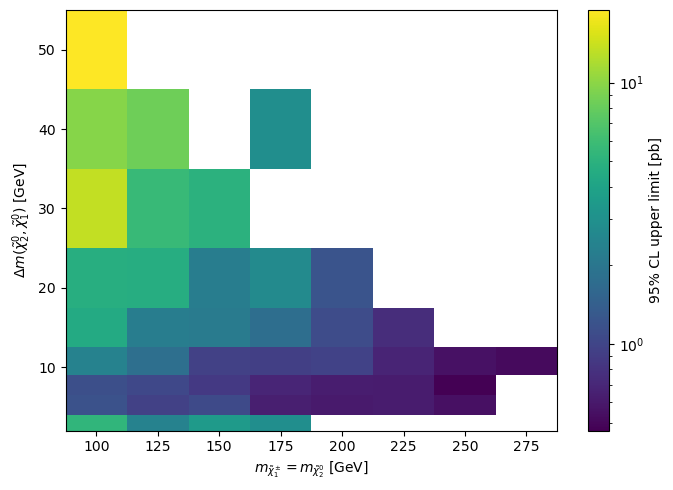

In [147]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LogNorm

x = r"$m_{\tilde{\chi}^\pm_1} = m_{\tilde{\chi}^0_2}$ [GeV]"
y = r"$\Delta m (\tilde{\chi}^0_2, \tilde{\chi}^0_1)$ [GeV]"
z = "95% CL upper limit on the cross section [pb]"

# pivot so rows = y-axis
grid = sus_18_004_mins_obs_merged_tmp.pivot(index=y, columns=x, values=z)

grid = grid.sort_index().sort_index(axis=1)

X = grid.columns.values
Y = grid.index.values
Z = grid.values

fig, ax = plt.subplots(figsize=(7,5))

pcm = ax.pcolormesh(X, Y, Z, shading="auto", cmap="viridis", norm=LogNorm())

cbar = fig.colorbar(pcm, ax=ax)
cbar.set_label("95% CL upper limit [pb]")

ax.set_xlabel(r"$m_{\tilde{\chi}_1^\pm}=m_{\tilde{\chi}_2^0}$ [GeV]")
ax.set_ylabel(r"$\Delta m(\tilde{\chi}_2^0,\tilde{\chi}_1^0)$ [GeV]")

plt.tight_layout()
plt.show()

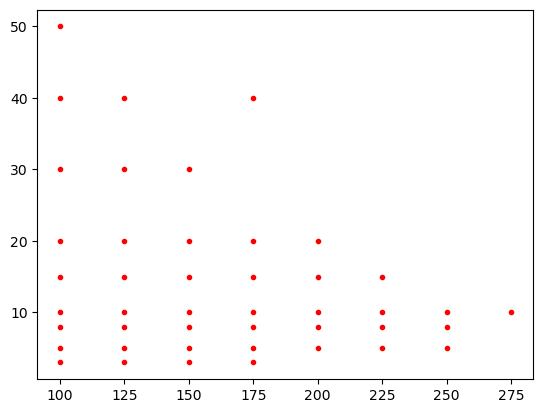

In [150]:
plt.plot(sus_18_004_mins_obs_merged_tmp[r'$m_{\tilde{\chi}^\pm_1} = m_{\tilde{\chi}^0_2}$ [GeV]'],
         sus_18_004_mins_obs_merged_tmp[r'$\Delta m (\tilde{\chi}^0_2, \tilde{\chi}^0_1)$ [GeV]'], 'r.')

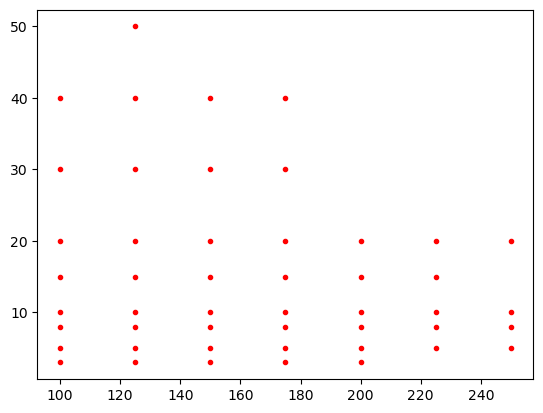

In [151]:
plt.plot(sus_18_004_plus_obs_merged_tmp[r'$m_{\tilde{\chi}^\pm_1} = m_{\tilde{\chi}^0_2}$ [GeV]'],
         sus_18_004_plus_obs_merged_tmp[r'$\Delta m (\tilde{\chi}^0_2, \tilde{\chi}^0_1)$ [GeV]'], 'r.')